# CAP 4770: Data Mining — Final Project
## US Apartment Rental Price Prediction

**Group Members:** Neil (Member A) | Katie (Member B) | Guerin (Member C)

**Dataset:** Apartments for Rent Classified — 99,637 records, 22 features

**Database:** Azure SQL — cap4770apartments.database.windows.net

---
### Notebook Sections
- **Section 1** — System Setup and Azure SQL Connection *(Neil)*
- **Section 2** — Data Loading and Validation *(Neil)*
- **Section 3** — Data Preprocessing and Cleaning *(Katie)*
- **Section 4** — Exploratory Data Analysis *(Katie)*
- **Section 5** — Data Modeling *(Guerin)*
- **Section 6** — Results and Interpretation *(Guerin)*

---
## Section 1 — System Setup and Azure SQL Connection
**Owner: Neil (Member A)**

Before we can connect to our cloud database, we need to install a few
Python libraries and a special Microsoft driver. This section handles
all of that setup and then establishes the connection to our Azure SQL database
where our apartment dataset lives.

> **Note:** After running the ODBC driver install cell, you must restart
> the Colab runtime before continuing. Go to Runtime > Restart session > Yes.
> Then re-run the pip install cell before moving forward.

In [1]:
# Install the two libraries we need to connect Python to our Azure SQL database
# sqlalchemy is a toolkit that helps Python talk to databases
# pyodbc is the driver that handles database communication
!pip install sqlalchemy pyodbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 5.1 MB/s eta 0:00:00


In [2]:
# Install the Microsoft ODBC Driver 17 for SQL Server
# Azure SQL databases require this specific Microsoft driver to accept connections

# Step 1: Add Microsoft's security key so our system trusts their packages
!curl https://packages.microsoft.com/keys/microsoft.asc | apt-key add -

# Step 2: Tell our system where to find Microsoft's software packages
!curl https://packages.microsoft.com/config/ubuntu/22.04/prod.list > /etc/apt/sources.list.d/mssql-release.list

# Step 3: Refresh the package list so it includes Microsoft's new packages
!apt-get update -q

# Step 4: Install the actual ODBC driver — ACCEPT_EULA=Y auto-accepts the license
!ACCEPT_EULA=Y apt-get install -y msodbcsql17

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100   975  100   975    0     0   3179      0 --:--:-- --:--:-- --:--:--  3175
OK
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    89  100    89    0     0    323      0 --:--:-- --:--:-- --:--:--   324
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://packages.microsoft.com/ubuntu/22.04/prod jammy InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu j

In [1]:
# Import the libraries we will use throughout the entire notebook
# Doing all imports at the top is a best practice so nothing breaks later
from sqlalchemy import create_engine
import urllib
import pandas as pd
import numpy as np

# Build the connection string that tells Python exactly how to reach our Azure database
# urllib.parse.quote_plus safely encodes special characters in the password
# so they do not break the connection string format
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=cap4770apartments.database.windows.net;"
    "DATABASE=cap4770apartments;"
    "UID=cap4770admin;"
    "PWD=Cap4770uwf!"
)

# Create the engine
# We reuse this engine object throughout the notebook whenever we need the database
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Quick test to make sure the connection is alive before we try to load any data
with engine.connect() as conn:
    print("Azure SQL connection successful")

Azure SQL connection successful


---
## Section 2 — Data Loading and Validation
**Owner: Neil (Member A)**

Now that we are connected to Azure SQL, we pull our full apartment dataset
into a pandas DataFrame. We then run a few checks to make sure all the
data came through correctly before passing it to Katie for cleaning.

In [2]:
# Pull every row from the apartments table in our Azure SQL database
# pd.read_sql runs the SQL query and automatically converts the result
# into a pandas DataFrame that we can work with in Python
df = pd.read_sql("SELECT * FROM apartments", con=engine)

# Print the shape to confirm we got all the rows and columns we expected
print(f"Dataset shape: {df.shape}")
print(f"Rows loaded: {len(df)}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (99637, 22)
Rows loaded: 99637
Columns: 22


In [3]:
# test query to double-check the connection is working
# and that the data looks correct before we start any analysis
# SELECT TOP 5 is SQL Server syntax for returning just the first 5 rows
try:
    df_test = pd.read_sql("SELECT TOP 5 * FROM apartments", engine)
    print("Azure SQL connection validated successfully")
    display(df_test)
except Exception as e:
    print("Connection validation failed:")
    print(e)

Azure SQL connection validated successfully


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5198357043,housing/rent/apartment,"Over 1,132 sf in Alexandria",The are the next step up You re not 1 to compr...,Elevator,2.0,2.0,USD,No,Yes,...,"$1,657",Monthly,1132,None,Alexandria,VA,38.8171,-77.1221,RentDigs.com,1550847349
1,5198355175,housing/rent/apartment,"Average Rent $1,824 a month - That's a STEAL!","Square footage: 1132 sq. feet, unit number: 04...",None,2.0,2.0,USD,No,Thumbnail,...,"$1,824",Monthly,1132,None,Alexandria,VA,38.7926,-77.0831,RentDigs.com,1550847197
2,5198355030,housing/rent/apartment,"1,132 sq. ft. - Two BR - convenient location. ...","Square footage: 1132 square feet, unit number:...",Parking,2.0,2.0,USD,No,Thumbnail,...,"$1,804",Monthly,1132,None,Alexandria,VA,38.7926,-77.0831,RentDigs.com,1550847186
3,5198353828,housing/rent/apartment,"Two BR - Artessa Apartment Homes in, CA.",Invites you to live life on your own terms. Th...,"Playground,Pool",2.0,2.0,USD,No,Thumbnail,...,"$1,794",Monthly,980,None,Riverside,CA,33.9248,-117.3975,RentDigs.com,1550847097
4,5198352584,housing/rent/apartment,"Two BR, Two BA, safe neighborhood",What makes us The Sterling Apartments. It s no...,"Elevator,Gym,Internet Access,Patio/Deck,Pool",2.0,2.0,USD,No,Thumbnail,...,"$1,150",Monthly,1193,None,Grand Island,NE,40.9254,-98.3790,RentDigs.com,1550847004


In [4]:
# Print all 22 column names to confirm the full dataset schema loaded from Azure SQL
print("Dataset columns:")
for col in df.columns:
    print(f"  - {col}")

Dataset columns:
  - id
  - category
  - title
  - body
  - amenities
  - bathrooms
  - bedrooms
  - currency
  - fee
  - has_photo
  - pets_allowed
  - price
  - price_display
  - price_type
  - square_feet
  - address
  - cityname
  - state
  - latitude
  - longitude
  - source
  - time


In [5]:
# df.info() gives us a summary of every column including its data type
# and how many non-null values it has
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99637 entries, 0 to 99636
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99637 non-null  int64  
 1   category       99637 non-null  object 
 2   title          99637 non-null  object 
 3   body           99637 non-null  object 
 4   amenities      83578 non-null  object 
 5   bathrooms      99574 non-null  float64
 6   bedrooms       99513 non-null  float64
 7   currency       99637 non-null  object 
 8   fee            99637 non-null  object 
 9   has_photo      99637 non-null  object 
 10  pets_allowed   39134 non-null  object 
 11  price          99636 non-null  float64
 12  price_display  99636 non-null  object 
 13  price_type     99637 non-null  object 
 14  square_feet    99637 non-null  int64  
 15  address        7931 non-null   object 
 16  cityname       99335 non-null  object 
 17  state          99335 non-null  object 
 18  latitu

In [6]:
# Count how many missing values exist in each column
# A high number here means will need to handle that column carefully in preprocessing
# price and square_feet are guaranteed to never be null
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                   0
category             0
title                0
body                 0
amenities        16059
bathrooms           63
bedrooms           124
currency             0
fee                  0
has_photo            0
pets_allowed     60503
price                1
price_display        1
price_type           0
square_feet          0
address          91706
cityname           302
state              302
latitude            25
longitude           25
source               0
time                 0
dtype: int64


---
## Section 3 — Data Preprocessing and Cleaning
**Owner: Katie (Member B)**

Raw data is rarely clean enough to use directly for analysis or modeling.
In this section we remove duplicates, handle missing values, and filter out
any listings with clearly invalid data like negative prices or zero square footage.
Every step is documented so the process is fully reproducible.

In [7]:
# copy of the original df before we make any changes
# means we can always go back to the raw data
# if something goes wrong during cleaning... we never modify df directly
df_clean = df.copy()
print(f"Working copy created: {df_clean.shape}")

Working copy created: (99637, 22)


In [8]:
# Check for duplicate rows
# multiple times which would unfairly influence our model if we kept them
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

# Remove any duplicates that were found
df_clean = df_clean.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")

Duplicate rows found: 84
Shape after removing duplicates: (99553, 22)


In [9]:
# Define  columns that matter most for our analysis and modeling
# We check these specifically because they are the features we plan to use
key_features = ['price', 'square_feet', 'bedrooms', 'bathrooms',
                'cityname', 'state', 'latitude', 'longitude']
print("Missing values in key features:")
print(df_clean[key_features].isnull().sum())

Missing values in key features:
price            1
square_feet      0
bedrooms       124
bathrooms       63
cityname       302
state          302
latitude        25
longitude       25
dtype: int64


In [10]:
# Drop any listings that are missing location information
# Location is one of our most important features for predicting price
# so a listing without a city, state, or coordinates is not useful
df_clean = df_clean.dropna(subset=['cityname', 'state', 'latitude', 'longitude'])
print(f"Shape after dropping rows with missing location data: {df_clean.shape}")

Shape after dropping rows with missing location data: (99251, 22)


In [11]:
# Fill in missing bedroom and bathroom values using the median
# the median instead of the mean because rental prices have outliers
# and the median is not affected by a few extremely large or small values
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].median())

print("Missing values after imputation:")
print(df_clean[['bedrooms', 'bathrooms']].isnull().sum())

Missing values after imputation:
bedrooms     0
bathrooms    0
dtype: int64


In [12]:
# Look at the price column statistics to understand the range and spot bad values
# looking for anything that does not make sense for a real apartment listing
print("Price summary statistics:")
print(df_clean['price'].describe())

# Remove any listings with a price of zero or below
df_clean = df_clean[df_clean['price'] > 0]
print(f"\nShape after removing invalid price values: {df_clean.shape}")

Price summary statistics:
count    99250.000000
mean      1525.706761
std        903.362579
min        100.000000
25%       1014.000000
50%       1350.000000
75%       1795.000000
max      52500.000000
Name: price, dtype: float64

Shape after removing invalid price values: (99250, 22)


In [13]:
# Look at the square footage column to check for invalid values
# An apartment with zero or negative square footage is clearly a data error
print("Square footage summary statistics:")
print(df_clean['square_feet'].describe())

# Remove listings with zero or negative square footage
df_clean = df_clean[df_clean['square_feet'] > 0]
print(f"\nShape after removing invalid square footage values: {df_clean.shape}")

Square footage summary statistics:
count    99250.000000
mean       956.042247
std        387.686723
min        101.000000
25%        729.000000
50%        900.000000
75%       1115.000000
max      40000.000000
Name: square_feet, dtype: float64

Shape after removing invalid square footage values: (99250, 22)


In [14]:
# Remove any rows where bedrooms or bathrooms are negative
df_clean = df_clean[df_clean['bedrooms'] >= 0]
df_clean = df_clean[df_clean['bathrooms'] >= 0]

print("Bedroom and bathroom summary after filtering:")
print(df_clean[['bedrooms', 'bathrooms']].describe())

Bedroom and bathroom summary after filtering:
           bedrooms     bathrooms
count  99250.000000  99250.000000
mean       1.728584      1.445199
std        0.748635      0.547067
min        0.000000      1.000000
25%        1.000000      1.000000
50%        2.000000      1.000000
75%        2.000000      2.000000
max        9.000000      9.000000


In [15]:
# Final check on the cleaned dataset before moving to analysis
print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"\nRemaining missing values:")
print(df_clean[key_features].isnull().sum())

# Save the cleaned dataset as a CSV backup
df_clean.to_csv("apartments_cleaned.csv", index=False)
print("\nCleaned dataset saved to apartments_cleaned.csv")

Final cleaned dataset shape: (99250, 22)

Remaining missing values:
price          0
square_feet    0
bedrooms       0
bathrooms      0
cityname       0
state          0
latitude       0
longitude      0
dtype: int64

Cleaned dataset saved to apartments_cleaned.csv


---
## Section 4 — Exploratory Data Analysis
**Owner: Katie (Member B)**

Before building any models, we explore the data visually and statistically
to understand what it looks like and what patterns exist. This helps us
make better decisions about how to build our models. We generate three
required plots plus a summary statistics table.

In [16]:
# Import matplotlib for creating our visualizations
import matplotlib.pyplot as plt

# Create a filtered version of the dataset just for plotting
# exclude extreme outliers like $50,000/month apartments because
# they compress the charts and make the main distribution hard to see
# We still use the full dataset for modeling. This filter is for visuals only
df_plot = df_clean[
    (df_clean['price'] < 5000) &
    (df_clean['square_feet'] < 3000)
]
print(f"Plotting dataset shape: {df_plot.shape}")

Plotting dataset shape: (98510, 22)


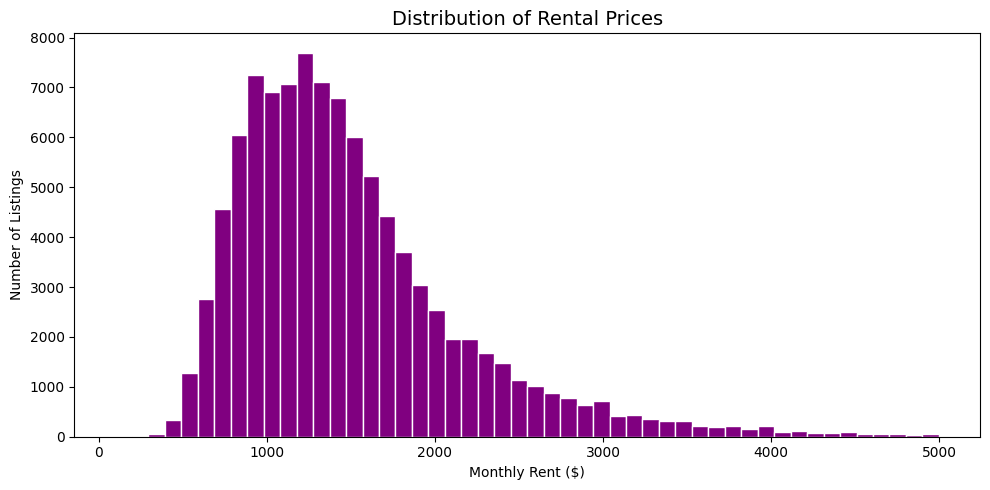

In [17]:
# Plot 1: Distribution of Rental Prices
# A histogram shows how many apartments fall into each price range
# This tells us whether prices are spread evenly or clustered in certain ranges
plt.figure(figsize=(10, 5))
plt.hist(df_plot['price'], bins=50, color='purple', edgecolor='white')
plt.title("Distribution of Rental Prices", fontsize=14)
plt.xlabel("Monthly Rent ($)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("plot1_price_distribution.png", dpi=150)
plt.show()

# Insight: Rental prices are right-skewed, meaning most listings cluster
# in the lower to mid price range with fewer high-priced listings pulling
# the distribution to the right. This is why we use the median as our
# reference point rather than the mean.

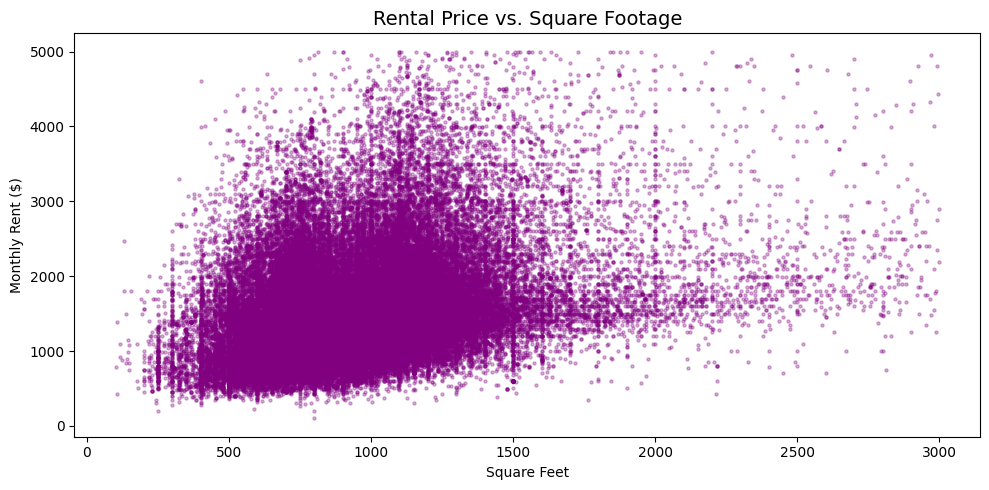

In [18]:
# Plot 2: Rental Price vs Square Footage
# A scatter plot shows the relationship between apartment size and price
# If bigger apartments consistently cost more, the dots will trend upward
# alpha=0.3 makes dots transparent so overlapping points are still visible
plt.figure(figsize=(10, 5))
plt.scatter(df_plot['square_feet'], df_plot['price'],
            alpha=0.3, color='purple', s=5)
plt.title("Rental Price vs. Square Footage", fontsize=14)
plt.xlabel("Square Feet")
plt.ylabel("Monthly Rent ($)")
plt.tight_layout()
plt.savefig("plot2_price_vs_sqft.png", dpi=150)
plt.show()

# Insight: There is a positive relationship between apartment size and price
# meaning larger apartments generally cost more. The relationship is not
# perfectly straight because other factors like location also influence price.

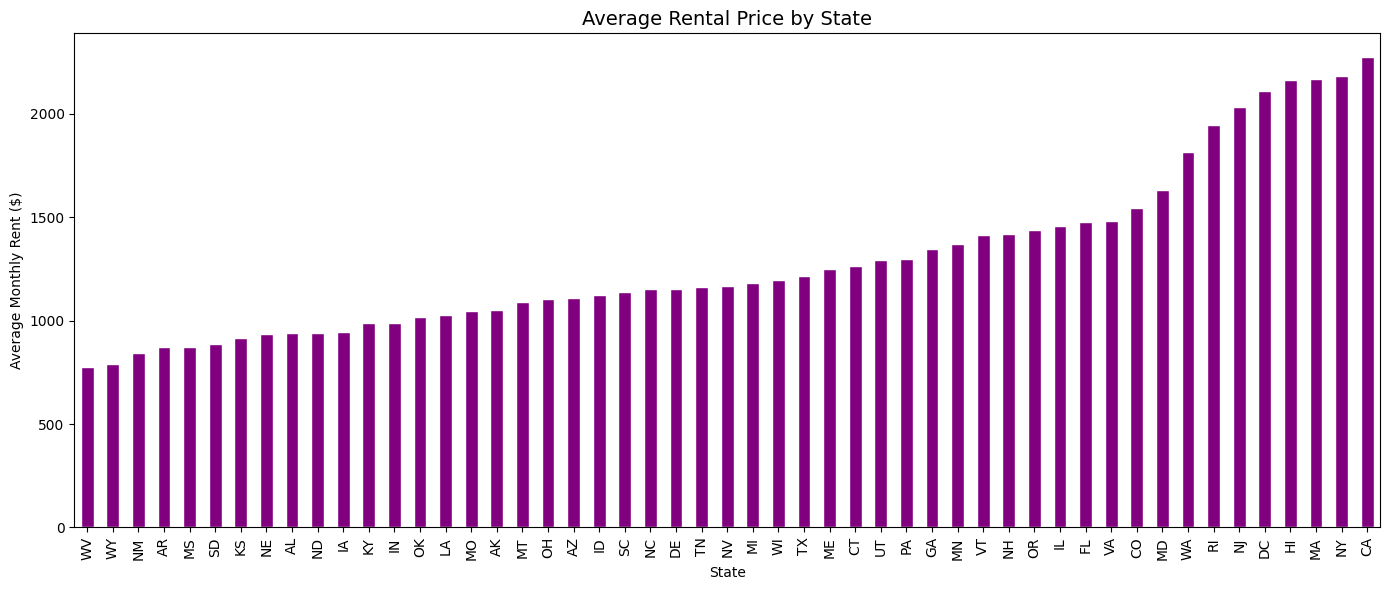

In [19]:
# Plot 3: Average Rental Price by State
# This bar chart shows which states have the highest and lowest average rent
# groupby calculates the mean price for each state
# sort_values arranges the bars from lowest to highest for easy comparison
avg_price_state = df_plot.groupby('state')['price'].mean().sort_values()

plt.figure(figsize=(14, 6))
avg_price_state.plot(kind='bar', color='purple', edgecolor='white')
plt.title("Average Rental Price by State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Average Monthly Rent ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("plot3_avg_price_by_state.png", dpi=150)
plt.show()

# Insight: Average rental prices vary significantly by state, confirming
# that location is a major driver of rental costs. Coastal states like
# California and Massachusetts are among the most expensive while
# southern and midwestern states tend to be more affordable.

In [20]:
# Summary statistics table for the four main numerical features
# describe() gives us count, mean, std, min, max, and quartile values
# round(2) keeps things clean and readable
print("Summary Statistics for Key Numerical Features:")
df_clean[['price', 'square_feet', 'bedrooms', 'bathrooms']].describe().round(2)

Summary Statistics for Key Numerical Features:


,price,square_feet,bedrooms,bathrooms
count,99250.00,99250.00,99250.00,99250.00
mean,1525.71,956.04,1.73,1.45
std,903.36,387.69,0.75,0.55
min,100.00,101.00,0.00,1.00
25%,1014.00,729.00,1.00,1.00
50%,1350.00,900.00,2.00,1.00
75%,1795.00,1115.00,2.00,2.00
max,52500.00,40000.00,9.00,9.00


---
## Section 5 — Data Modeling
**Owner: Guerin (Member C)**

In this section we build and train three different machine learning models
to predict apartment rental prices. We start with a simple baseline model
and work up to more complex ones. Each model is evaluated using the same
metrics so we can fairly compare them at the end.

In [21]:
# Import all the machine learning tools we need from scikit-learn
# scikit-learn is the most widely used Python library for machine learning
# and it has built-in implementations of all three models we are using
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Modeling libraries imported successfully")

Modeling libraries imported successfully


In [22]:
# Select the features we want to use for modeling
# We chose square_feet, bedrooms, bathrooms, and state because
# the EDA showed these are the strongest predictors of rental price
# We drop text columns like title and body because models cannot learn from raw text
df_model = df_clean[['price', 'square_feet', 'bedrooms',
                      'bathrooms', 'state']].dropna()

# Apply a log transformation to the price column
# Rental prices have extreme outliers (like $52,500/month) that can throw off
# the models. Taking the log compresses that wide range and helps the models
# learn more stable patterns. We convert back to dollars for reporting.
# np.log1p is used instead of np.log to avoid errors on any zero values
df_model['log_price'] = np.log1p(df_model['price'])

# Convert the state column into separate yes/no columns for each state
# Machine learning models need numbers, not text like 'CA' or 'TX'
# One-hot encoding creates a column for each state with 1 meaning yes and 0 meaning no
# drop_first=True removes one state column to avoid mathematical redundancy
df_model = pd.get_dummies(df_model, columns=['state'], drop_first=True)

# Separate into X (input features) and y (what we are trying to predict)
X = df_model.drop(columns=['price', 'log_price'])
y = df_model['log_price']

print(f"Modeling dataset shape: {df_model.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Target: log_price  mean={y.mean():.4f}  std={y.std():.4f}")

Modeling dataset shape: (99250, 55)
Number of features: 53
Target: log_price  mean=7.2261  std=0.4382


In [23]:
# Split the data into a training set and a test set
# We use 80% of the data to teach the models and hold back 20% to test them
# The test set is data the models have never seen — like a practice exam vs the real exam
# random_state=42 makes sure we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set:     {X_test.shape[0]} records")

Training set: 79400 records
Test set:     19850 records


In [24]:
# Model 1: Linear Regression (Baseline)
# Linear Regression draws a straight line through the data to make predictions
# It is the simplest model we can use and serves as our starting point
# Any model we build after this should perform better than this baseline

# Linear Regression is sensitive to feature scale — for example, square footage
# (in the hundreds) would dominate bedroom count (usually 1-4) without scaling
# StandardScaler fixes this by converting all features to the same scale
# We fit the scaler on the training data only so the test data stays truly unseen
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train the model — this is where the model learns from the training data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Make predictions on the test set and convert from log scale back to dollars
y_pred_lr_log = lr.predict(X_test_scaled)
y_pred_lr = np.expm1(y_pred_lr_log)

# Convert the actual test prices back to dollars for a fair comparison
# y_test_actual is used by all three models for evaluation
y_test_actual = np.expm1(y_test)

print("── Linear Regression Results ──")
print(f"Training set size:  {len(X_train)}")
print(f"Test set size:      {len(X_test)}")
print(f"MAE:  ${mean_absolute_error(y_test_actual, y_pred_lr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_actual, y_pred_lr)):.2f}")
print(f"R\u00b2:   {r2_score(y_test_actual, y_pred_lr):.4f}")

── Linear Regression Results ──
Training set size:  79400
Test set size:      19850
MAE:  $351.34
RMSE: $710.46
R²:   0.3312


In [25]:
# Model 2: Decision Tree
# A Decision Tree works like a flowchart — it asks a series of yes/no questions
# about the features (like 'is square footage > 1000?' or 'is the state CA?')
# until it arrives at a price prediction
# This handles non-linear patterns that Linear Regression cannot capture

# max_depth=15 was chosen after testing depths from 4 to unlimited
# It gave the best balance between learning enough patterns and not memorizing
# the training data (a problem called overfitting)
# min_samples_split=20 means a branch only splits if at least 20 listings
# share that path — this prevents the tree from making rules based on too few examples
dt = DecisionTreeRegressor(max_depth=15, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)

# Make predictions and convert from log scale back to actual dollar values
y_pred_dt_log = dt.predict(X_test)
y_pred_dt = np.expm1(y_pred_dt_log)

print("── Decision Tree Results ──")
print(f"MAE:  ${mean_absolute_error(y_test_actual, y_pred_dt):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_actual, y_pred_dt)):.2f}")
print(f"R\u00b2:   {r2_score(y_test_actual, y_pred_dt):.4f}")

── Decision Tree Results ──
MAE:  $338.43
RMSE: $697.38
R²:   0.3556


In [26]:
# Model 3: Random Forest
# A Random Forest builds many decision trees (200 in our case) and averages
# their predictions together. A single tree can memorize quirks in the training
# data but when you average 200 trees those quirks cancel out.
# This makes Random Forest more accurate and more stable than a single tree.

# n_estimators=200 means we build 200 trees — more trees = more stable results
# max_depth=10 keeps each individual tree from going too deep and overfitting
# min_samples_split=20 prevents splits on very small groups of listings
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           min_samples_split=20, random_state=42)
rf.fit(X_train, y_train)

# Make predictions and convert from log scale back to actual dollar values
y_pred_rf_log = rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

print("── Random Forest Results ──")
print(f"MAE:  ${mean_absolute_error(y_test_actual, y_pred_rf):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_actual, y_pred_rf)):.2f}")
print(f"R\u00b2:   {r2_score(y_test_actual, y_pred_rf):.4f}")

── Random Forest Results ──
MAE:  $349.91
RMSE: $665.98
R²:   0.4123


In [27]:
# Cross-Validation on Random Forest
# A single train/test split can sometimes get lucky or unlucky depending on which
# listings end up in each set. Cross-validation solves this by splitting the
# training data into 5 equal parts and testing 5 different times.
# The average of those 5 scores gives a much more reliable performance estimate.
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')

print("── Random Forest Cross-Validation (5-Fold) ──")
print(f"R\u00b2 scores across 5 folds: {cv_scores.round(4)}")
print(f"Mean R\u00b2:   {cv_scores.mean():.4f}")
print(f"Std Dev:   {cv_scores.std():.4f}")
# A low standard deviation means the model performs consistently
# regardless of which data it trains on — this is a sign of a stable model

── Random Forest Cross-Validation (5-Fold) ──
R² scores across 5 folds: [0.5341 0.5435 0.5253 0.5457 0.5417]
Mean R²:   0.5381
Std Dev:   0.0075


---
## Section 6 — Results and Interpretation
**Owner: Guerin (Member C)**

With all three models trained and evaluated, we now compare their performance
side by side, visualize the results, and interpret what the numbers mean
in the context of our original problem statement.

In [35]:
# Build a comparison table showing all three metrics for all three models
# MAE = how many dollars off on average
# RMSE = similar to MAE but punishes large errors more heavily
# R² = what percentage of price variation the model explains (higher is better)
# All metrics are calculated on actual dollar values not log values
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test_actual, y_pred_lr),
        mean_absolute_error(y_test_actual, y_pred_dt),
        mean_absolute_error(y_test_actual, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_actual, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_actual, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
    ],
    'R\u00b2': [
        r2_score(y_test_actual, y_pred_lr),
        r2_score(y_test_actual, y_pred_dt),
        r2_score(y_test_actual, y_pred_rf)
    ]
})

results = results.round(4)
print("── Model Comparison Summary ──")
print(results.to_string(index=False))

── Model Comparison Summary ──
            Model      MAE     RMSE     R²
Linear Regression 351.3373 710.4580 0.3312
    Decision Tree 338.4337 697.3780 0.3556
    Random Forest 349.9082 665.9843 0.4123


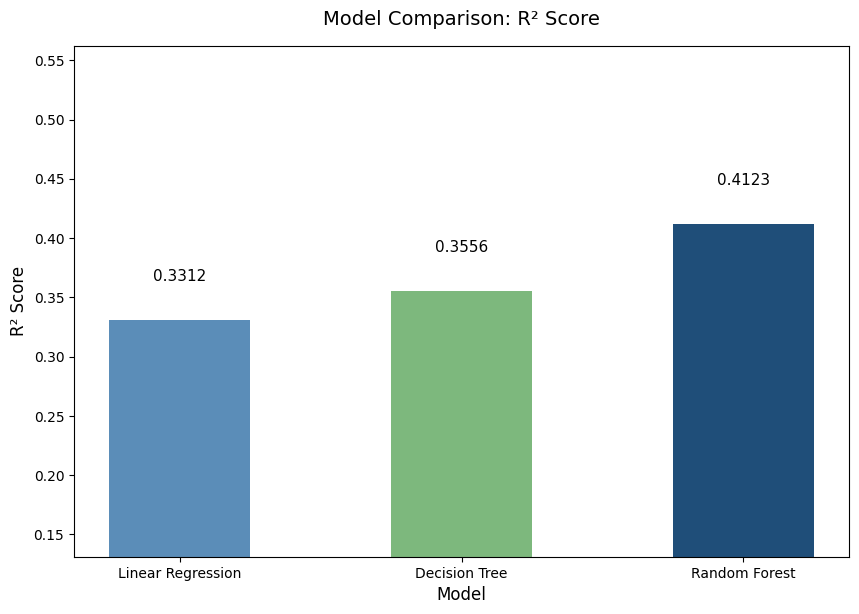

In [36]:
# Bar chart comparing R² scores across all three models
# R² is the best single metric for comparing models because it is easy to interpret
# A score of 1.0 means perfect predictions, 0 means no better than guessing the average
models = results['Model'].tolist()
r2_scores = results['R\u00b2'].tolist()
colors = ['#5B8DB8', '#7DB87D', '#1F4E79']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(models, r2_scores, color=colors, width=0.5)

# Set y-axis range to fit all values including any negative scores
y_min = min(r2_scores) - 0.2
y_max = max(r2_scores) + 0.15
ax.set_ylim(y_min, y_max)

# Dashed line at zero helps visually identify models below baseline performance
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_title("Model Comparison: R\u00b2 Score", fontsize=14, pad=15)
ax.set_ylabel("R\u00b2 Score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)

# Add the exact R² value as a label on top of each bar
for bar, val in zip(bars, r2_scores):
    offset = 0.03 if val >= 0 else -0.08
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + offset,
            str(round(val, 4)),
            ha='center', va='bottom', fontsize=11)

plt.subplots_adjust(top=0.88, bottom=0.15)
plt.savefig("plot4_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

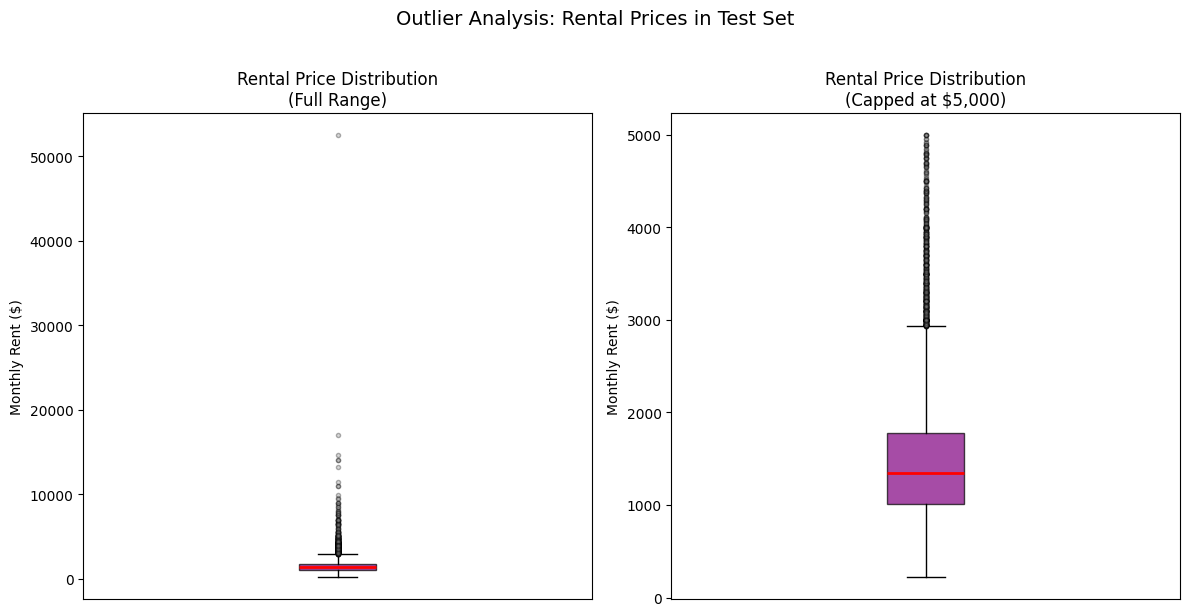

Q1:            $1007.00
Median:        $1349.00
Q3:            $1789.75
IQR:           $782.75
Lower bound:   $-167.12
Upper bound:   $2963.87
Outliers:      879 of 19850 listings (4.4%)


In [37]:
# Boxplot showing the distribution of actual rental prices in the test set
# A boxplot is a great way to visualize spread and outliers in one chart
# The box covers the middle 50% of prices, the line inside is the median,
# and the dots outside the whiskers are outliers
# We show two versions: full range to see all outliers, and capped at $5,000
# to show the main distribution more clearly
y_test_dollars = np.expm1(y_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left chart: full price range including all outliers
axes[0].boxplot(y_test_dollars, vert=True, patch_artist=True,
                boxprops=dict(facecolor='purple', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markersize=3, alpha=0.3))
axes[0].set_title("Rental Price Distribution\n(Full Range)", fontsize=12)
axes[0].set_ylabel("Monthly Rent ($)")
axes[0].set_xticks([])

# Right chart: capped at $5,000 to make the main distribution easier to read
axes[1].boxplot(y_test_dollars[y_test_dollars <= 5000],
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='purple', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markersize=3, alpha=0.3))
axes[1].set_title("Rental Price Distribution\n(Capped at $5,000)", fontsize=12)
axes[1].set_ylabel("Monthly Rent ($)")
axes[1].set_xticks([])

plt.suptitle("Outlier Analysis: Rental Prices in Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plot4b_price_boxplot.png", dpi=150)
plt.show()

# Print the IQR-based outlier statistics
# IQR (Interquartile Range) is the standard statistical method for identifying outliers
# Any value more than 1.5 times the IQR above Q3 or below Q1 is considered an outlier
q1 = y_test_dollars.quantile(0.25)
q3 = y_test_dollars.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = y_test_dollars[
    (y_test_dollars < lower_bound) | (y_test_dollars > upper_bound)
]

print(f"Q1:            ${q1:.2f}")
print(f"Median:        ${y_test_dollars.median():.2f}")
print(f"Q3:            ${q3:.2f}")
print(f"IQR:           ${iqr:.2f}")
print(f"Lower bound:   ${lower_bound:.2f}")
print(f"Upper bound:   ${upper_bound:.2f}")
print(f"Outliers:      {len(outliers)} of {len(y_test_dollars)} listings ({len(outliers)/len(y_test_dollars)*100:.1f}%)")

Points shown: 19752 of 19850 total test listings


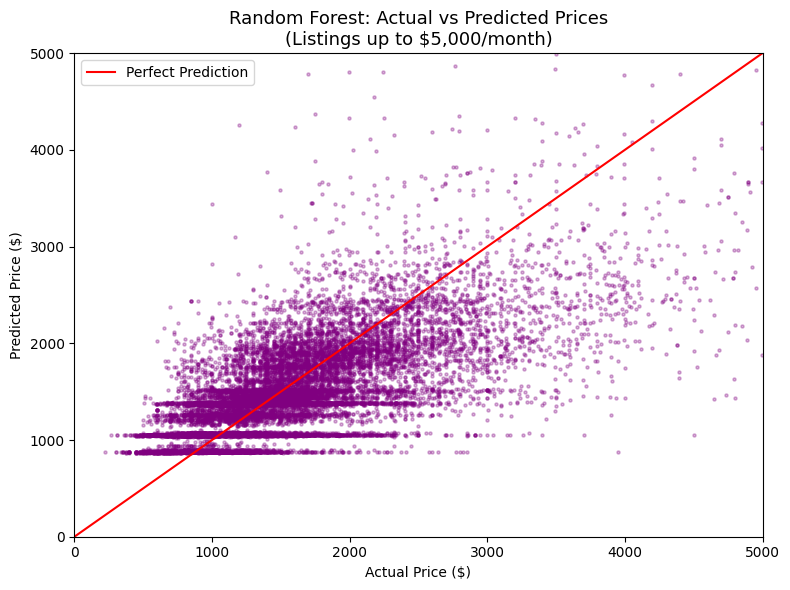

In [41]:
# Scatter plot: Actual vs Predicted Prices for the Random Forest model
# Each dot represents one apartment listing in the test set
# If the model predicted perfectly, every dot would sit on the red diagonal line
# Dots above the line mean the model over-predicted, dots below mean under-predicted
# We cap the display at $5,000 to focus on the majority of listings

cap = 5000

# Convert both to numpy arrays first to avoid index alignment issues
y_test_arr = np.expm1(y_test.values)
y_pred_arr = np.array(y_pred_rf)

# Apply the cap filter using array indexing instead of Series indexing
mask = (y_test_arr <= cap) & (y_pred_arr <= cap)
y_test_plot = y_test_arr[mask]
y_pred_plot = y_pred_arr[mask]

print(f"Points shown: {mask.sum()} of {len(y_test_arr)} total test listings")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_plot, y_pred_plot, alpha=0.3, color='purple', s=5)
plt.plot([0, cap], [0, cap], color='red', linewidth=1.5, label='Perfect Prediction')
plt.title("Random Forest: Actual vs Predicted Prices\n(Listings up to $5,000/month)",
          fontsize=13)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.xlim(0, cap)
plt.ylim(0, cap)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_actual_vs_predicted.png", dpi=150)
plt.show()

Median rental price (classification threshold): $1349.00


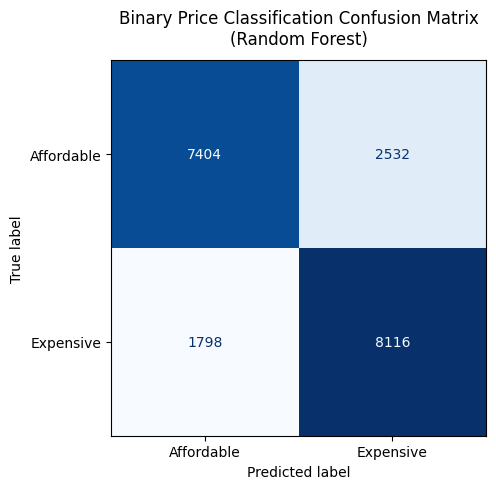


Confusion Matrix Summary:
  True Negatives  (Affordable correctly predicted): 7,404
  False Positives (Affordable predicted as Expensive): 2,532
  False Negatives (Expensive predicted as Affordable): 1,798
  True Positives  (Expensive correctly predicted): 8,116

  Overall Accuracy: 0.7819 (78.2%)


In [42]:
# Binary Confusion Matrix for the Random Forest model
# A confusion matrix shows us how often the model gets the classification right or wrong
# We convert our price predictions into two categories:
# Affordable = at or below the median price of $1,349/month
# Expensive = above the median price of $1,349/month
# This gives us the classic 2x2 confusion matrix covered in class
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the median as our dividing line between Affordable and Expensive
median_price = y_test_actual.median()
print(f"Median rental price (classification threshold): ${median_price:.2f}")

# Convert dollar predictions to binary labels: 1 = Expensive, 0 = Affordable
actual_binary    = (y_test_actual > median_price).astype(int)
predicted_binary = (pd.Series(y_pred_rf) > median_price).astype(int)

# Build the confusion matrix
cm = confusion_matrix(actual_binary, predicted_binary)

# Plot it
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Affordable', 'Expensive']
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title("Binary Price Classification Confusion Matrix\n(Random Forest)",
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("plot6_confusion_matrix.png", dpi=150)
plt.show()

# Print a plain English breakdown of what each cell in the matrix means
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"\nConfusion Matrix Summary:")
print(f"  True Negatives  (Affordable correctly predicted): {tn:,}")
print(f"  False Positives (Affordable predicted as Expensive): {fp:,}")
print(f"  False Negatives (Expensive predicted as Affordable): {fn:,}")
print(f"  True Positives  (Expensive correctly predicted): {tp:,}")
print(f"\n  Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

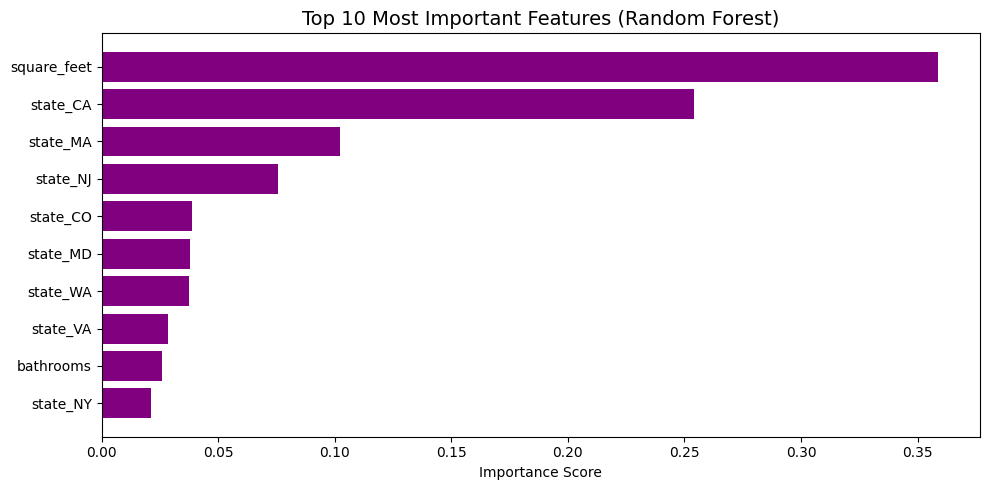


Top 10 Features by Importance:
    Feature  Importance
square_feet    0.358809
   state_CA    0.253907
   state_MA    0.102261
   state_NJ    0.075647
   state_CO    0.038738
   state_MD    0.037870
   state_WA    0.037390
   state_VA    0.028469
  bathrooms    0.025710
   state_NY    0.021381


In [40]:
# Feature Importance Chart for the Random Forest model
# Feature importance tells us which input variables the model relied on most
# when making its predictions. A higher score means that feature had more
# influence on the predicted price.
# This is useful for understanding what actually drives rental prices in our data.
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

# Horizontal bar chart makes it easy to read the feature names
plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'][::-1],
         feature_importance['Importance'][::-1],
         color='purple')
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot7_feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 Features by Importance:")
print(feature_importance.to_string(index=False))